# Delivery Analysis

This notebook analyzes order delivery performance and its impact on customer experience.

## Delivery Performance

Delivery performance is evaluated based on the time taken to deliver an order to the customer and whether the order was delivered by the estimated delivery date.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv"
)

reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv"
)

customers = pd.read_csv(
    DATA_DIR / "olist_customers_dataset.csv"
)

In [2]:
orders.shape, reviews.shape

((99441, 8), (99224, 7))

In [3]:
orders[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
delivery_status = (
    orders
    .groupby("order_status")
    .agg(
        orders=("order_id", "count"),
        delivered_date=("order_delivered_customer_date", "count")
    )
    .sort_values("orders", ascending=False)
)

delivery_status

,orders,delivered_date
order_status,,
delivered,96478,96470
shipped,1107,0
canceled,625,6
unavailable,609,0
invoiced,314,0
processing,301,0
created,5,0
approved,2,0


In [5]:
orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].isna().sum()

order_purchase_timestamp            0
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
delivered_orders = orders[
    (orders["order_status"] == "delivered")
    & (orders["order_delivered_customer_date"].notna())
].copy()

In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

delivered_orders[date_columns] = delivered_orders[date_columns].apply(
    pd.to_datetime
)

In [8]:
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [9]:
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [10]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

In [11]:
delivered_orders["delivery_delay_days"].describe()

count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64

In [12]:
(
    delivered_orders["delivery_delay_days"] > 0
).mean()

np.float64(0.08112366538820359)

In [13]:
import matplotlib.pyplot as plt

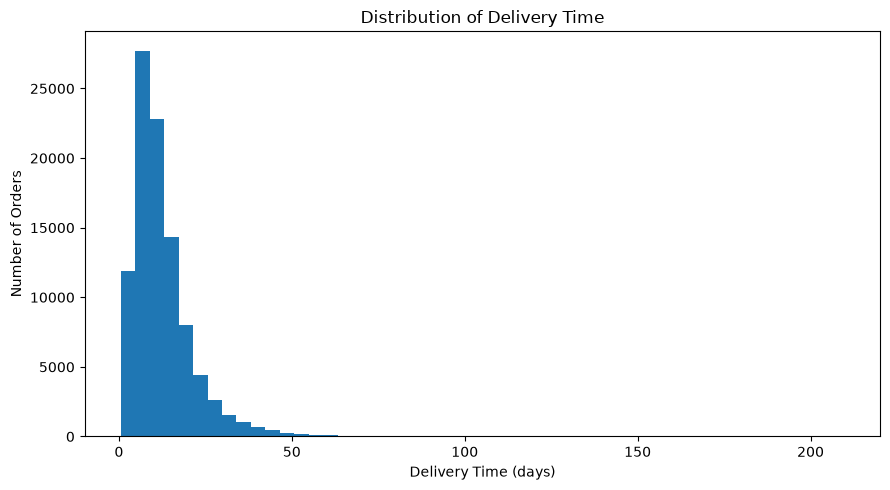

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(
    delivered_orders["delivery_days"],
    bins=50
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [15]:
(delivered_orders["delivery_days"] > 30).sum()

np.int64(4550)

In [16]:
(delivered_orders["delivery_days"] > 60).sum()

np.int64(306)

In [17]:
delivered_orders["purchase_month"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [18]:
monthly_delivery = (
    delivered_orders
    .groupby("purchase_month")
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_rate=("delivery_delay_days", lambda x: (x > 0).mean()),
        orders=("order_id", "count")
    )
    .reset_index()
)

monthly_delivery

,purchase_month,avg_delivery_days,median_delivery_days,late_rate,orders
0,2016-09,54.813194,54.813194,1.000000,1
1,2016-10,19.600559,17.944282,0.011321,265
2,2016-12,4.693021,4.693021,0.000000,1
3,2017-01,12.647044,10.733646,0.030667,750
4,2017-02,13.168825,10.971204,0.032063,1653
5,2017-03,12.951184,10.126487,0.055774,2546
6,2017-04,14.917913,12.748623,0.078593,2303
7,2017-05,11.322363,9.793333,0.036107,3545
8,2017-06,12.011573,10.804907,0.038596,3135
9,2017-07,11.592732,10.158073,0.034349,3872


In [19]:
delivery_by_state = delivered_orders[
    ["order_id", "customer_id", "delivery_days", "delivery_delay_days"]
].merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [20]:
delivery_by_state[
    ["order_id", "customer_id", "customer_state"]
].head()

,order_id,customer_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP


In [21]:
state_delivery = (
    delivery_by_state
    .groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_rate=("delivery_delay_days", lambda x: (x > 0).mean())
    )
    .sort_values("orders", ascending=False)
)

state_delivery

,orders,avg_delivery_days,median_delivery_days,late_rate
customer_state,,,,
SP,40494,8.761386,7.210272,0.058947
RJ,12350,15.309438,12.041644,0.134737
MG,11354,12.008666,10.313513,0.056104
RS,5344,15.300276,13.177488,0.071482
PR,4923,11.991582,10.425509,0.049970
SC,3546,14.954783,13.014352,0.097575
BA,3256,19.335466,16.913964,0.140356
DF,2080,12.967568,11.364925,0.070673
ES,1995,15.789307,13.636956,0.122306


In [22]:
state_delivery_main = (
    state_delivery[
        state_delivery["orders"] >= 1000
    ]
    .sort_values("avg_delivery_days")
)

state_delivery_main

,orders,avg_delivery_days,median_delivery_days,late_rate
customer_state,,,,
SP,40494,8.761386,7.210272,0.058947
PR,4923,11.991582,10.425509,0.049970
MG,11354,12.008666,10.313513,0.056104
DF,2080,12.967568,11.364925,0.070673
SC,3546,14.954783,13.014352,0.097575
RS,5344,15.300276,13.177488,0.071482
RJ,12350,15.309438,12.041644,0.134737
GO,1957,15.606339,13.949606,0.081758
ES,1995,15.789307,13.636956,0.122306


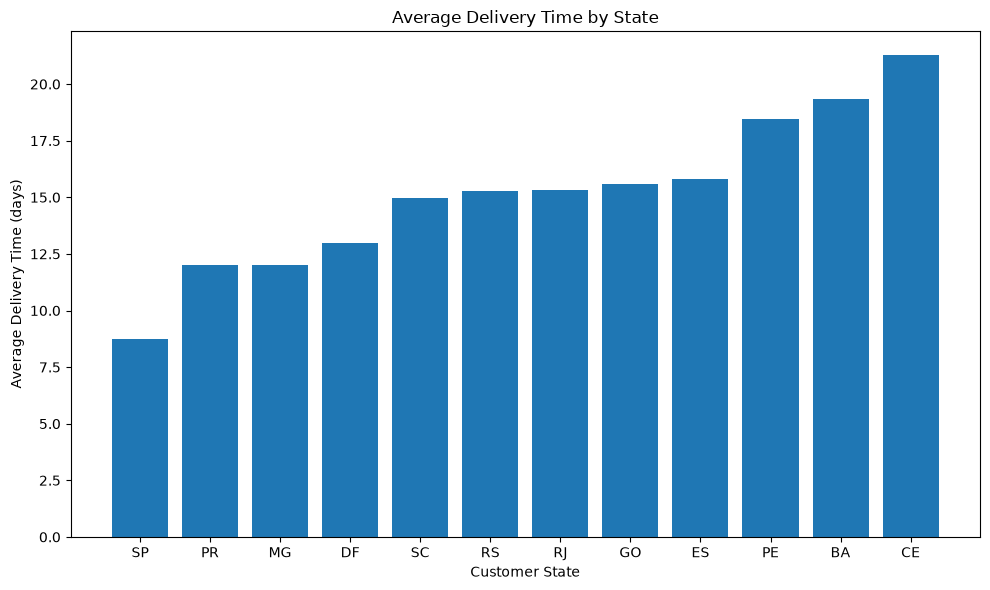

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    state_delivery_main.index,
    state_delivery_main["avg_delivery_days"]
)

plt.title("Average Delivery Time by State")
plt.xlabel("Customer State")
plt.ylabel("Average Delivery Time (days)")
plt.tight_layout()
plt.show()

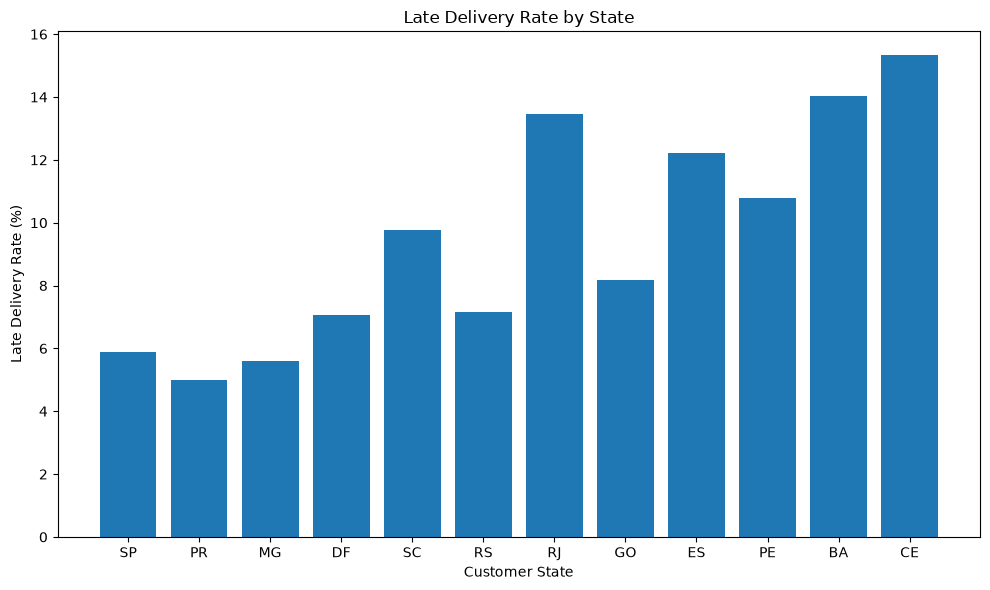

In [24]:
plt.figure(figsize=(10, 6))

plt.bar(
    state_delivery_main.index,
    state_delivery_main["late_rate"] * 100
)

plt.title("Late Delivery Rate by State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.tight_layout()
plt.show()

In [25]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [26]:
reviews["order_id"].value_counts().head(10)

order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
169d7e0fd71d624d306f132acd791cbe    2
1c308eca3f339414a92e518e2a2e5ee9    2
2002ea16e75277eaa0b5d78632048540    2
1d297b4800ed1a3c5b0944d84c01ee99    2
0176a6846bcb3b0d3aa3116a9a768597    2
Name: count, dtype: int64

In [27]:
review_duplicates = (
    reviews[reviews["order_id"].duplicated(keep=False)]
    .groupby("order_id")["review_score"]
    .agg(["count", "nunique"])
)

review_duplicates["nunique"].value_counts()

nunique
1    345
2    202
Name: count, dtype: int64

In [28]:
order_reviews = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

In [29]:
delivery_reviews = delivered_orders[
    ["order_id", "delivery_delay_days"]
].merge(
    order_reviews,
    on="order_id",
    how="inner",
    validate="one_to_one"
)

In [30]:
delivery_reviews.shape

(95824, 3)

In [31]:
delivery_reviews["review_score"].isna().sum()

np.int64(0)

In [32]:
review_by_delivery = (
    delivery_reviews
    .assign(
        delivery_status=lambda df: df["delivery_delay_days"]
            .gt(0)
            .map({True: "Late", False: "On-time"})
    )
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
)

review_by_delivery

,orders,avg_review_score,median_review_score
delivery_status,,,
Late,7661,2.566506,2.0
On-time,88163,4.294292,5.0


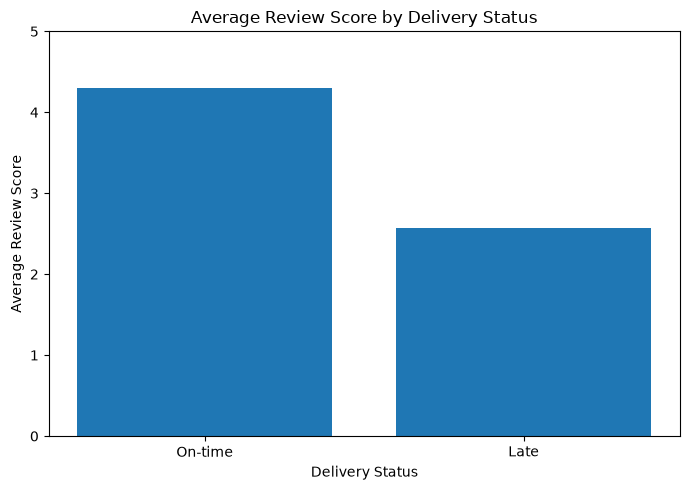

In [33]:
plt.figure(figsize=(7, 5))

avg_review = (
    review_by_delivery["avg_review_score"]
    .reindex(["On-time", "Late"])
)

plt.bar(
    avg_review.index,
    avg_review.values
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

## Key Finding

Late deliveries are strongly associated with lower customer review scores. Orders delivered after the estimated date received an average review score of 2.57, compared with 4.29 for on-time deliveries.

This indicates that delivery performance is closely related to customer satisfaction, although the analysis does not establish a causal relationship.